###   Опросы


In [1]:
import pandas as pd
import numpy as np
import math

import matplotlib
import matplotlib.pyplot as plt
import random


%matplotlib inline
import os
os.chdir("C:/Users/olesh/data_analys/GI")

In [2]:
excel_df = pd.read_excel('опрос_режим.xlsx', sheet_name = 'Ответы', index_col=False)
excel_df = excel_df.rename(columns={"Отметка времени": "Время"})


In [3]:
hours_order = [
    "меньше 5 часов",
    "5-10 часов",
    "10-20 часов",
    "20+ часов"
]

excel_df["Сколько часов вы уже сыграли в новом режиме?"] = pd.Categorical(
    excel_df["Сколько часов вы уже сыграли в новом режиме?"],
    categories=hours_order,
    ordered=True
)

difficulty_order = [
    "Легко",
    "Обычно",
    "Сложно",
    "Опасно"
]

excel_df["Какой максимальный уровень сложности вы успешно проходили?"] = pd.Categorical(
    excel_df["Какой максимальный уровень сложности вы успешно проходили?"],
    categories=difficulty_order,
    ordered=True
)

excel_df["Какой уровень сложности вы используете для фарма?"] = pd.Categorical(
    excel_df["Какой уровень сложности вы используете для фарма?"],
    categories=difficulty_order,
    ordered=True
)

profit_order = [
    "менее 1 млн",
    "1-2 млн",
    "2-3 млн",
    "3-5 млн",
    "более 5 млн"
]

excel_df["Каков ваш максимальный доход за одну вылазку?"] = pd.Categorical(
    excel_df["Каков ваш максимальный доход за одну вылазку?"],
    categories=profit_order,
    ordered=True
)

invest_order = [
    "0",
    "0-500к",
    "500к-1млн",
    "1-2 млн",
    "2-2,5 млн"
]

excel_df["Сколько вы инвестируете на уровне сложности опасно?"] = pd.Categorical(
    excel_df["Сколько вы инвестируете на уровне сложности опасно?"],
    categories=invest_order,
    ordered=True
)

long_play_order = [
    "Нисколько",
    "Пока не завершу главный сюжет",
    "Пока не завершу главный сюжет и не заберу Эйдосы Пироиса",
    "Пока не закрою большую часть контента, в том числе указанное выше",
    "Пока не зкарою весь контент",
    "Продолжу даже после закрытия контента",
]

excel_df["Сколько вы планируете играть в этот режим? Если не знаете, пропустите вопрос"] = pd.Categorical(
    excel_df["Сколько вы планируете играть в этот режим? Если не знаете, пропустите вопрос"],
    categories=long_play_order,
    ordered=True
)

In [4]:
col = "Что вам понравилось в режиме?"
excel_df.loc[excel_df[col].str.contains("Ничего не понравилось", na=False),col] = "Ничего не понравилось"

col = "Что вам НЕ понравилось в режиме?"
excel_df.loc[excel_df[col].str.contains("Все понравилось", na=False), col] = "Все понравилось"

### Средняя оценка

In [5]:
print('средняя оценка: ', excel_df['Дайте оценку режима в целом'].mean())

средняя оценка:  3.623411978221416


In [6]:
#hours_rate = excel_df[['Дайте оценку режима в целом', 'Сколько часов вы уже сыграли в новом режиме?']]
result = ( excel_df.groupby('Сколько часов вы уже сыграли в новом режиме?', observed=False)
    .agg(
        Средняя=("Дайте оценку режима в целом", "mean"),
        Количество=("Дайте оценку режима в целом", "count")))

result

,Средняя,Количество
Сколько часов вы уже сыграли в новом режиме?,,
меньше 5 часов,3.032922,243
5-10 часов,3.723356,441
10-20 часов,3.765152,264
20+ часов,4.025974,154


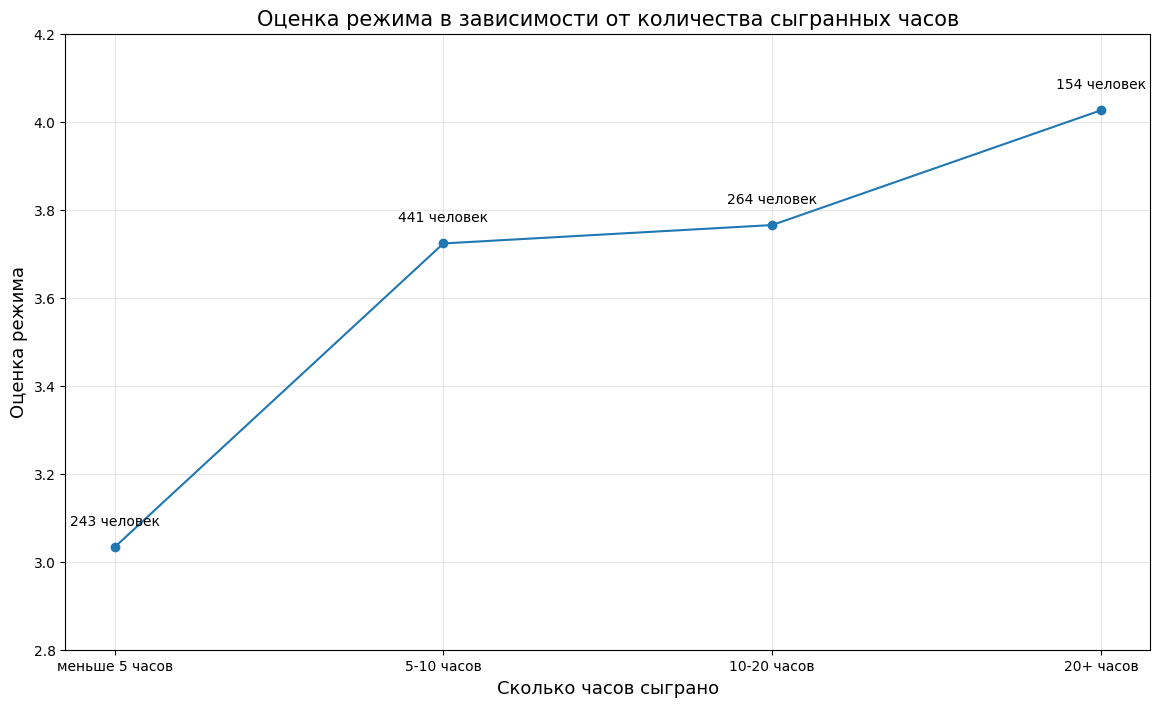

In [7]:
plt.figure(figsize=(14, 8))

plt.plot(result.index, result["Средняя"], marker="o")

for i, (_, row) in enumerate(result.iterrows()):
    plt.text(
        i,
        row["Средняя"] + 0.05,
        f'{int(row["Количество"])} человек',
        ha="center",
        fontsize=10
    )

plt.grid(alpha=0.3)
plt.ylim(2.8, 4.2)
plt.xlabel("Сколько часов сыграно", fontsize=13)
plt.ylabel("Оценка режима", fontsize=13)
plt.title("Оценка режима в зависимости от количества сыгранных часов", fontsize=15)

plt.show()

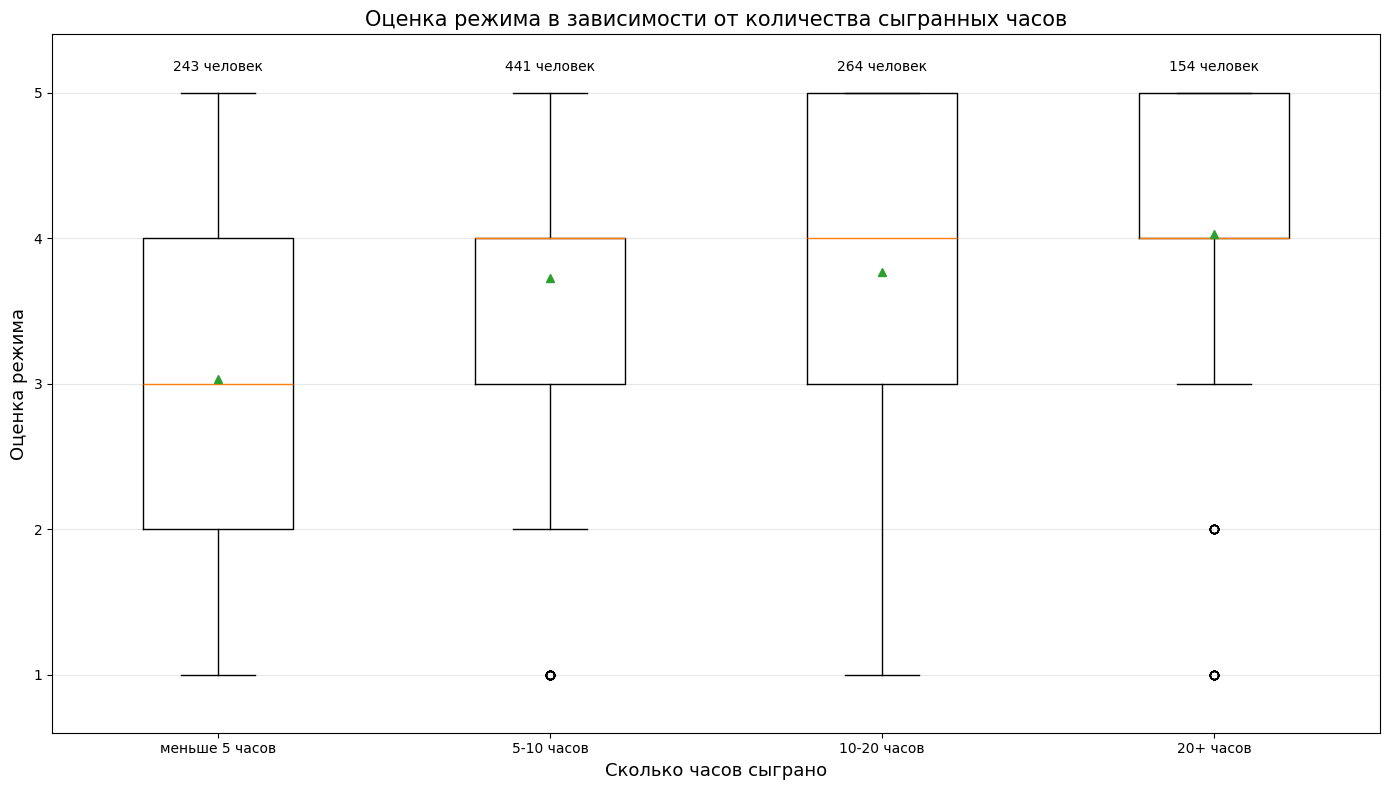

In [8]:
hours_col = "Сколько часов вы уже сыграли в новом режиме?"
rating_col = "Дайте оценку режима в целом"

# Убираем строки, где нет оценки или категории часов
plot_df = excel_df[[hours_col, rating_col]].dropna()

plt.figure(figsize=(14, 8))

# Данные для каждой категории в правильном порядке
categories = plot_df[hours_col].cat.categories

data = [
    plot_df.loc[plot_df[hours_col] == category, rating_col]
    for category in categories
]

# Boxplot
bp = plt.boxplot(
    data,
    tick_labels=categories,
    showmeans=True,     # показываем среднее
    meanline=False      # среднее будет точкой, а не линией
)

# Число людей над каждым boxplot
for i, values in enumerate(data, start=1):
    if len(values) == 0:
        continue

    plt.text(
        i,
        values.max() + 0.15,
        f"{len(values)} человек",
        ha="center",
        fontsize=10
    )

plt.ylim(0.6, 5.4)
plt.xlabel("Сколько часов сыграно", fontsize=13)
plt.ylabel("Оценка режима", fontsize=13)
plt.title("Оценка режима в зависимости от количества сыгранных часов", fontsize=15)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Что понравилось

In [9]:
likes = excel_df['Что вам понравилось в режиме?'].str.split(", ")
likes_count  = likes.explode().value_counts()
likes_count 

Что вам понравилось в режиме?
Ощущение опасности и риска потери ресурсов при вылазке в каверну    631
Сложность                                                           437
Гринд                                                               388
Прокачка Люмихаба и экипировки                                      347
Главный сюжет                                                       327
Ничего не понравилось                                               174
Побочные задание                                                    130
Name: count, dtype: int64

### Что не понравилось

In [10]:
not_likes = excel_df['Что вам НЕ понравилось в режиме?'].str.split(", ")
not_likes_count  = not_likes.explode().value_counts()
not_likes_count 

Что вам НЕ понравилось в режиме?
Гринд                                                               546
Прокачка Люмихаба и экипировки                                      436
Побочные задание                                                    265
Все понравилось                                                     206
Сложность                                                           186
Главный сюжет                                                       179
Ощущение опасности и риска потери ресурсов при вылазке в каверну    171
Name: count, dtype: int64

### Эфирные фантомы

In [11]:
phantoms = excel_df['Какими Эфирными фантомами вы пользуетесь чаще всего?'].str.split(", ")
phantoms_count  = phantoms.explode().value_counts()
phantoms_count 

Какими Эфирными фантомами вы пользуетесь чаще всего?
Опалённый              354
Первозданный кошмар    290
Золотой банбу          279
Фракиец                220
Шут                    206
Взломуравей-мутант     137
Собек                  103
Скорпион               103
Оголтелый силач         95
Ненарекаемая            90
Хейтор                  77
Кровавый чистильщик     73
Name: count, dtype: int64

### Эфирные фантомы, сложность "Опсано"

In [12]:
phantoms = excel_df[excel_df['Какой максимальный уровень сложности вы успешно проходили?'] == 'Опасно']['Какими Эфирными фантомами вы пользуетесь чаще всего?'].str.split(", ")
phantoms_count  = phantoms.explode().value_counts()
phantoms_count 

Какими Эфирными фантомами вы пользуетесь чаще всего?
Первозданный кошмар    181
Опалённый              171
Золотой банбу          137
Фракиец                126
Шут                     89
Собек                   47
Взломуравей-мутант      40
Ненарекаемая            38
Скорпион                36
Хейтор                  26
Оголтелый силач         22
Кровавый чистильщик     20
Name: count, dtype: int64

### Эфирные фантомы, 20+ часов

In [13]:
phantoms = excel_df[excel_df['Сколько часов вы уже сыграли в новом режиме?'] == '20+ часов']['Какими Эфирными фантомами вы пользуетесь чаще всего?'].str.split(", ")
phantoms_count  = phantoms.explode().value_counts()
phantoms_count 

Какими Эфирными фантомами вы пользуетесь чаще всего?
Первозданный кошмар    80
Опалённый              80
Золотой банбу          59
Фракиец                58
Шут                    35
Собек                  23
Ненарекаемая           19
Взломуравей-мутант     17
Скорпион               17
Хейтор                 12
Кровавый чистильщик     9
Оголтелый силач         7
Name: count, dtype: int64

### Клинок аберрации

In [14]:
sword = excel_df['Каким клинком аберрации вы пользуетесь чаще всего?'].str.split(", ")
sword_count  = sword.explode().value_counts()
sword_count 

Каким клинком аберрации вы пользуетесь чаще всего?
Мощный удар    520
Блок           296
Рывок          209
Name: count, dtype: int64

### Таблицы

In [15]:
table = pd.crosstab(
    excel_df["Сколько часов вы уже сыграли в новом режиме?"],
    excel_df["Какой максимальный уровень сложности вы успешно проходили?"]
)

table.style \
    .background_gradient(cmap="Greens", axis=1) \
    .set_properties(**{"text-align": "center"})

Какой максимальный уровень сложности вы успешно проходили?,Легко,Обычно,Сложно,Опасно
Сколько часов вы уже сыграли в новом режиме?,,,,
меньше 5 часов,67,108,57,11
5-10 часов,3,66,267,105
10-20 часов,0,9,101,154
20+ часов,0,0,22,132


In [25]:
table = pd.crosstab(
    excel_df["Сколько часов вы уже сыграли в новом режиме?"],
    excel_df["Какой уровень сложности вы используете для фарма?"]
)

table.style \
    .background_gradient(cmap="Greens", axis=1) \
    .set_properties(**{"text-align": "center"})

Какой уровень сложности вы используете для фарма?,Легко,Обычно,Сложно,Опасно
Сколько часов вы уже сыграли в новом режиме?,,,,
меньше 5 часов,58,114,37,10
5-10 часов,5,106,277,47
10-20 часов,1,17,170,75
20+ часов,1,1,70,82


In [17]:
table = pd.crosstab(
    excel_df["Сколько часов вы уже сыграли в новом режиме?"],
    excel_df["Каков ваш максимальный доход за одну вылазку?"]
)

table.style \
    .background_gradient(cmap="Greens", axis=1) \
    .set_properties(**{"text-align": "center"})

Каков ваш максимальный доход за одну вылазку?,менее 1 млн,1-2 млн,2-3 млн,3-5 млн,более 5 млн
Сколько часов вы уже сыграли в новом режиме?,,,,,
меньше 5 часов,178,51,8,3,3
5-10 часов,76,212,119,28,6
10-20 часов,6,67,97,67,27
20+ часов,1,13,34,52,54


In [18]:
table = pd.crosstab(
    excel_df["Сколько вы инвестируете на уровне сложности опасно?"],
    excel_df["Каков ваш максимальный доход за одну вылазку?"]
)

table.style \
    .background_gradient(cmap="Greens") \
    .set_properties(**{"text-align": "center"})

Каков ваш максимальный доход за одну вылазку?,менее 1 млн,1-2 млн,2-3 млн,3-5 млн,более 5 млн
Сколько вы инвестируете на уровне сложности опасно?,,,,,
0-500к,55,96,78,24,4
500к-1млн,19,66,79,46,21
1-2 млн,2,23,20,40,16
"2-2,5 млн",2,3,10,24,46


In [19]:
table = pd.crosstab(
    excel_df["Сколько часов вы уже сыграли в новом режиме?"],
    excel_df["Сколько вы планируете играть в этот режим? Если не знаете, пропустите вопрос"]
)

table.style \
    .background_gradient(cmap="Greens", axis=1) \
    .set_properties(**{"text-align": "center"})

"Сколько вы планируете играть в этот режим? Если не знаете, пропустите вопрос",Нисколько,Пока не завершу главный сюжет,Пока не завершу главный сюжет и не заберу Эйдосы Пироиса,"Пока не закрою большую часть контента, в том числе указанное выше",Пока не зкарою весь контент,Продолжу даже после закрытия контента
Сколько часов вы уже сыграли в новом режиме?,,,,,,
меньше 5 часов,21,11,79,68,57,5
5-10 часов,7,5,51,144,180,48
10-20 часов,4,2,16,92,123,22
20+ часов,3,0,3,28,77,42


### Были ли баги?

In [38]:
x = excel_df["Сталкивались ли вы с багами?"].value_counts()
num = 100* x['да']/(x['да'] + x['нет'])
string = "{0:.2f}%"
print(string.format(num))

53.55%
